---
title: "Chapter 2: From Data to a First Model"
---

::: {.callout-lo} 

By the end of this chapter, you should be able to:

- define examples, features, targets, predictions, training, and error;
- represent a supervised learning problem using a feature table $X$ and target vector $y$;
- distinguish classification from regression and supervised from unsupervised learning;
- build a baseline and explain why it is an essential reference point;
- use the `scikit-learn` `fit`–`predict`–`score` pattern while recognizing that `score` is model-dependent;
- explain at a high level how a decision tree learns rules and makes predictions;
- distinguish model parameters from hyperparameters; and
- interpret tree depth and decision boundaries as representations of model complexity.

:::

**Imports**

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("code"))

import mglearn
from IPython.display import HTML, display
from plotting_functions import *
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from utils import *

plt.rcParams["font.size"] = 16
pd.set_option("display.max_colwidth", 200)

%matplotlib inline

DATA_DIR = "data/"

## From a dataset to a first model

Machine learning uses a large vocabulary for a small number of recurring ideas. We will introduce that vocabulary through one running example, establish a simple baseline, and then train our first learned model: a decision tree.

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/YNT8n4cXu4A) introduces the terminology used in this section.
:::

### Representing a supervised learning problem

A supervised learning problem begins with examples for which the outcome is already known. We represent the available information as features and the outcome we want to predict as a target. A learning algorithm uses these examples to construct a model that can make predictions for new cases.

### Running example: quiz-grade prediction

For our first model, imagine that students want to anticipate whether they will receive an A+ on Quiz 2. They collect data from a previous offering containing attendance, lab grades, Quiz 1 performance, and the eventual Quiz 2 result. Before looking at the data, pause and identify which quantity is the target, which attributes could be features, and which of those features would actually be available before Quiz 2.

We will use three small datasets in this and the next chapter:

- [Quiz 2 classification data](data/quiz2-grade-toy-classification.csv)
- [Quiz 2 regression data](data/quiz2-grade-toy-regression.csv)
- [Canada–USA cities data](data/canada_usa_cities.csv)

These deliberately small datasets let us inspect every step. Later chapters use larger, messier datasets.

::: {.callout-note}
Supporting plotting functions live in `book/code/` so that the chapter can focus on the modeling ideas. The code remains available for inspection and reuse.
:::

The classification version asks whether a student will receive an A+ rather than predicting the exact grade. Each row describes one student from a previous offering.

In [2]:
classification_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-classification.csv")
print(classification_df.shape)
classification_df.head()

(21, 8)


,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


### Rows, features, and targets

Supervised-learning data is often organized as a table. Rows are **examples**, input columns are **features**, and the column we want to predict is the **target**.

![](img/sup-ml-terminology.png)

**Feature**
: An input characteristic available to the model. The feature table is conventionally denoted by $X$, and the number of features by $d$.

**Target**
: The outcome we want to predict, conventionally denoted by $y$.

**Example**
: One observation, represented by a row of feature values. The number of examples is conventionally denoted by $n$.

**Training**
: The process through which a learning algorithm uses $X$ and $y$ to determine a model's parameters. Training is also called *fitting*.

#### Separating the feature table and target

In [3]:
classification_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-classification.csv")
classification_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


Before fitting a supervised model, we separate the feature table `X` from the target vector `y`. Keeping this distinction explicit helps prevent the answer from accidentally becoming an input to the model.

In [4]:
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]
X.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,1,1,92,93,84,91,92
1,1,0,94,90,80,83,91
2,0,0,78,85,83,80,80
3,0,1,91,94,92,91,89
4,0,1,77,83,90,92,85


In [5]:
y.head()

0        A+
1    not A+
2    not A+
3        A+
4        A+
Name: quiz2, dtype: str

#### A second example: housing-price prediction

The same representation applies when the target is numerical. Here, each row represents a house, the property attributes form `X`, and price is `y`.

In [6]:
housing_df = pd.read_csv(DATA_DIR + "kc_house_data.csv")
housing_df.drop(["id", "date"], axis=1, inplace=True)
HTML(housing_df.head().to_html(index=False))

price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
X = housing_df.drop(columns=["price"])
y = housing_df["price"]
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [8]:
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [9]:
X.shape

(21613, 18)

::: {.callout-important}
Column names are meaningful to people, but most estimators operate on the feature values. A descriptive name does not make a feature informative, and an ambiguous name does not prevent its values from influencing a model.
:::

### A compact terminology guide

Different communities often use different words for the same role:

- **examples** = rows = samples = records = instances;
- **features** = inputs = predictors = explanatory variables = covariates;
- **targets** = outputs = outcomes = responses; categorical targets are often called labels; and
- **training** = learning = fitting.

The surrounding context determines which meaning is intended.

::: {.callout-tip title="See also"}
The [MDS terminology guide](https://ubc-mds.github.io/resources_pages/terminology/) provides a broader cross-disciplinary glossary.
:::

### Supervised and unsupervised learning

In **supervised learning**, the training data contains features $X$ and corresponding targets $y$. The goal is to learn a mapping that predicts the target for new examples.

In **unsupervised learning**, the observations have no designated target. The goal may instead be to find groups, discover structure, or construct a concise representation of the data. We return to unsupervised learning later in the book.

### Classification and regression

Supervised problems are commonly distinguished by the kind of target:

- **Classification** predicts one of two or more discrete classes—for example, liver disease versus no liver disease, or A+ versus not A+.
- **Regression** predicts a numerical quantity—for example, a house price or percentage grade.

The distinction affects which estimators and evaluation measures are appropriate.

![](img/classification-vs-regression.png)
<!-- <img src="img/classification-vs-regression.png" height="1500" width="1500">  -->

In [10]:
# quiz2 classification toy data
classification_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-classification.csv")
classification_df.head(4)

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+


In [11]:
# quiz2 regression toy data
regression_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-regression.csv")
regression_df.head(4)

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,90
1,1,0,94,90,80,83,91,84
2,0,0,78,85,83,80,80,82
3,0,1,91,94,92,91,89,92


In [12]:
classification_df

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+
5,1,0,70,73,68,74,71,not A+
6,1,0,80,88,89,88,91,A+
7,0,1,95,93,69,79,75,not A+
8,0,0,97,90,94,99,80,not A+
9,1,1,95,95,94,94,85,not A+


In [13]:
classification_df.shape

(21, 8)

### Prediction and statistical inference

**Prediction** asks what outcome a model should assign to a new example. **Statistical inference** asks what the observed data supports us in concluding about relationships, effects, or populations. For example, predicting recovery time is different from estimating whether a treatment causes recovery to happen sooner.

The goals can complement one another, but strong predictive performance does not by itself establish a causal explanation. In deployed machine-learning systems, the word *inference* is also sometimes used for the act of generating predictions with an already-fitted model; that operational usage is distinct from statistical inference.

### Exercise 2.1: Is machine learning suitable?

Select all problems for which machine learning could be a suitable component. Be prepared to state what examples the system could learn from and where human judgment or explicit rules should remain involved.

- (A) Identifying objects in digital images.
- (B) Determining eligibility for a service governed by complete, stable, and explicit rules.
- (C) Flagging unusual transaction patterns for fraud investigation.
- (D) Flagging possible abnormalities in medical images for expert review.
- (E) Providing empathetic support for a person experiencing a mental-health crisis.

::: {.callout-tip collapse="true" title="Solution"}
A, C, and D have learnable patterns and plausible sources of labeled examples. B is naturally rule-based when the rules are complete and stable. E requires context, empathy, and accountability that should not be delegated to a predictive model, although carefully scoped tools might support a qualified human.
:::

### Exercise 2.2: Supervised or unsupervised?

Select all examples of supervised learning.

- (A) Finding groups of similar properties in a real-estate dataset.
- (B) Predicting heart-attack risk from demographic, dietary, and clinical measurements.
- (C) Grouping news articles by topic.
- (D) Detecting credit-card fraud from labeled fraudulent and non-fraudulent transactions.
- (E) Using measured employee performance to investigate which recorded factors predict it.

::: {.callout-tip collapse="true" title="Solution"}
B, D, and E are supervised because each requires an observed target. E emphasizes interpretation, so predictive associations should not automatically be treated as causal effects.
:::

### Exercise 2.3: Classification or regression?

Select all regression problems.

- (A) Predicting the price of a house.
- (B) Predicting whether a house will sell.
- (C) Predicting a student's percentage grade.
- (D) Predicting whether to bicycle tomorrow.
- (E) Predicting an appropriate numerical thermostat setting.

::: {.callout-tip collapse="true" title="Solution"}
A, C, and E have numerical targets and are therefore regression problems.
:::

### Exercise 2.4: Define the representation

For each problem below, identify one possible unit of analysis, a target, and several features that would be available at prediction time:

1. sentiment analysis;
2. fraud detection; and
3. face recognition.

Are any of the proposed features ethically sensitive, unavailable at prediction time, or likely to encode the target indirectly?

## Establishing a baseline

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/6eT5cLL-2Vc) develops the baseline example in this section.
:::

We are now ready to build a simple supervised model for the quiz-grade problem. Before trying a sophisticated method, we need a reference point that tells us what performance can be achieved with almost no learning.

In [14]:
classification_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-classification.csv")
classification_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


In [15]:
classification_df["quiz2"].value_counts()

quiz2
not A+    11
A+        10
Name: count, dtype: int64

The label “not A+” is more common. A strategy that always predicts this majority class ignores every feature, but it may still achieve substantial accuracy. That makes it a useful sanity check.

### Why start with a baseline?

**Baseline**
: A simple reference strategy against which more elaborate models can be compared.

For classification, a common baseline always predicts the most frequent training label. A useful learned model should improve on an appropriate baseline in a way that matters for the problem.

### A classification baseline with `DummyClassifier`

`scikit-learn` provides `DummyClassifier` for simple classification baselines. We will fit a most-frequent baseline to the quiz-grade data.

### The `scikit-learn` model-building pattern

Most estimators follow the same interface:

1. construct the feature table `X` and target `y`;
2. create an estimator;
3. call `fit(X, y)` to learn from the training data;
4. call `predict(X_new)` to predict new examples; and
5. evaluate predictions with an appropriate measure.

#### Reading the data

In [16]:
classification_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+


#### Create $X$ and $y$

- $X$ &rarr; Feature vectors
- $y$ &rarr; Target

In [17]:
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]

#### Create a classifier object

- `import` the appropriate classifier 
- Create an object of the classifier 

In [18]:
from sklearn.dummy import DummyClassifier  # import the classifier

dummy_clf = DummyClassifier(strategy="most_frequent")  # Create a classifier object

#### `fit` the classifier

- The "learning" is carried out when we call `fit` on the classifier object. 

In [19]:
dummy_clf.fit(X, y)
# fit the classifier

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.48,0.52]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","['A+','not A+']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](7,)","['ml_experience','class_attendance','lab1',...,'lab3','lab4','quiz1']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,7
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


#### `predict` the target of given examples

- We can predict the target of examples by calling `predict` on the classifier object. 

In [20]:
dummy_clf.predict(X)  # predict using the trained classifier

array(['not A+', 'not A+', 'not A+', 'not A+', 'not A+', 'not A+',
       'not A+', 'not A+', 'not A+', 'not A+', 'not A+', 'not A+',
       'not A+', 'not A+', 'not A+', 'not A+', 'not A+', 'not A+',
       'not A+', 'not A+', 'not A+'], dtype='<U6')

#### Evaluating with `score`

An estimator's `score` method provides a convenient default measure, but its meaning depends on the estimator. For classifiers it is usually accuracy—the proportion of correctly predicted targets:

$$
	ext{accuracy} = 
rac{	ext{correct predictions}}{	ext{total predictions}}.
$$

Always check what `score` returns before interpreting it as model quality.

In [21]:
print("The accuracy of the model on the training data: %0.3f" % (dummy_clf.score(X, y)))

The accuracy of the model on the training data: 0.524


Classification **error** is often defined as $1 - 	ext{accuracy}$. Calling a classifier's `score(X, y)` typically runs `predict(X)`, compares the predictions with `y`, and returns accuracy.

For now we evaluate on the same small dataset used for fitting. This demonstrates the API, but it does **not** tell us how well the model will work on new data. Chapter 3 addresses that central problem.

In [22]:
print(
    "The error of the model on the training data: %0.3f" % (1 - dummy_clf.score(X, y))
)

The error of the model on the training data: 0.476


#### The `fit`, `predict`, and `score` pattern

The complete baseline workflow is shown below.

In [23]:
# Create `X` and `y` from the given data
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]

clf = DummyClassifier(strategy="most_frequent")  # Create a class object
clf.fit(X, y)  # Train/fit the model
print(clf.score(X, y))  # Assess the model

new_examples = [[0, 1, 92, 90, 95, 93, 92], [1, 1, 92, 93, 94, 92]]
clf.predict(new_examples)  # Predict on some new data using the trained model

0.5238095238095238


array(['not A+', 'not A+'], dtype='<U6')

::: {.callout-note}
You will investigate classification baselines more fully in the exercises and lab.
:::

### A regression baseline with `DummyRegressor`

For regression, `DummyRegressor` can predict a constant such as the training-set mean or median. Its default `score` is $R^2$, not accuracy.

The code below applies the same `fit` and `predict` pattern to the numerical version of the quiz-grade problem.

In [24]:
from sklearn.dummy import DummyRegressor

regression_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-regression.csv")  # Read data
X = regression_df.drop(columns=["quiz2"])  # Create `X` and `y` from the given data
y = regression_df["quiz2"]
reg = DummyRegressor()  # Create a class object
reg.fit(X, y)  # Train/fit the model
reg.score(X, y)  # Assess the model
new_examples = [[0, 1, 92, 90, 95, 93, 92], [1, 1, 92, 93, 94, 92]]
reg.predict(new_examples)  # Predict on some new data using the trained model

array([86.28571429, 86.28571429])

`fit` and `predict` play the same roles for regression and classification, but the default score differs. For regressors, `score` normally returns [$R^2$](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html):

- $R^2=1$ represents perfect predictions;
- a mean-prediction baseline usually has $R^2=0$ on the data used to evaluate that mean; and
- $R^2<0$ means the predictions are worse than predicting that mean.

We study regression evaluation measures in detail later in the book.

In [25]:
reg.score(X, y)

0.0

### Exercise 2.5: Order the modeling steps

Put the following steps in a sensible order:

- call `score` with labeled evaluation data;
- call `predict` on new examples;
- create an estimator;
- construct `X` and `y`; and
- call `fit`.

## Learning rules with decision trees

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/Hcf19Ij35rA) introduces decision trees.
:::

### From hand-written rules to learned rules

Can we do better than the majority-class baseline? One option is to write nested `if`/`else` rules using attendance and previous grades. To make the idea easy to visualize, first imagine that the feature values have been converted to binary indicators.

![](img/quiz2-grade-toy.png)

Look for combinations that distinguish A+ from not A+. A hand-written program might begin like this:

```python
if class_attendance == 1 and quiz1 == 1:
    prediction = "A+"
elif class_attendance == 1 and lab3 == 1 and lab4 == 1:
    prediction = "A+"
else:
    prediction = "not A+"
```

Even with seven binary features, the number of possible combinations becomes difficult to manage.

A decision tree learns a hierarchy of these questions from examples rather than requiring us to enumerate the rules by hand. Before fitting one, inspect the examples above: which single yes/no question seems most effective at separating A+ from not A+? A useful question creates groups whose outcomes are more homogeneous than the original group.

### The decision-tree idea

A decision tree resembles the [Twenty Questions](https://en.wikipedia.org/wiki/Twenty_questions) game. At each node it asks a question about one feature and follows a branch based on the answer. Training determines which questions to ask; prediction follows the learned path to an answer.

### Building decision trees with `sklearn`

Let's binarize our toy dataset for simplicity. 

In [26]:
classification_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-classification.csv")
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]

X_binary = X.copy()
columns = ["lab1", "lab2", "lab3", "lab4", "quiz1"]
for col in columns:
    X_binary[col] = X_binary[col].apply(lambda x: 1 if x >= 90 else 0)
X_binary.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,1,1,1,1,0,1,1
1,1,0,1,1,0,0,1
2,0,0,0,0,0,0,0
3,0,1,1,1,1,1,0
4,0,1,0,0,1,1,0


In [27]:
y.head()

0        A+
1    not A+
2    not A+
3        A+
4        A+
Name: quiz2, dtype: str

#### `DummyClassifier` on quiz2 grade prediction toy dataset 

In [28]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_binary, y)
dummy_clf.score(X_binary, y)

0.5238095238095238

#### `DecisionTreeClassifier` on quiz2 grade prediction toy dataset 

In [29]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()  # Create a decision tree
model.fit(X_binary, y)  # Fit a decision tree
model.score(X_binary, y)  # Assess the model

0.9047619047619048

The decision tree has much higher **training accuracy** than the dummy baseline. That is encouraging, but it does not yet establish that the tree will predict new students well. We will return to this distinction at the end of the chapter.

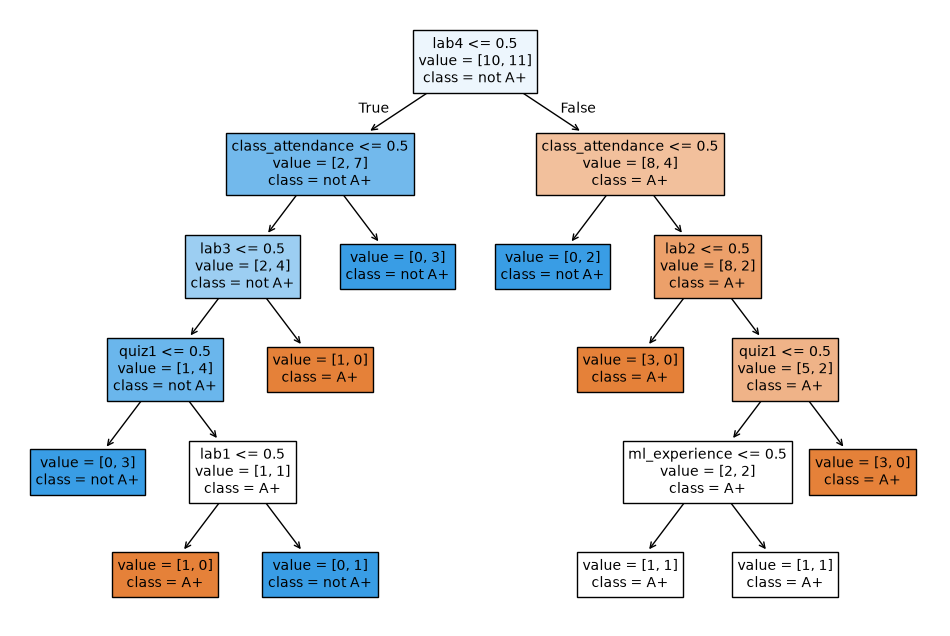

In [30]:
# Call the custom_plot_tree function to visualize the customized tree
width = 12
height = 8
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

### Reading a decision tree

**Root node**
: The first question asked by the tree.

**Branch**
: A connection representing the result of a question.

**Internal node**
: A subsequent question within the tree.

**Leaf node**
: The prediction produced after following a path through the tree.

**Tree depth**
: The number of edges on the longest path from the root to a leaf.

### How does prediction work?

In [31]:
new_example = np.array([[0, 1, 0, 0, 1, 1, 1]])
pd.DataFrame(data=new_example, columns=X.columns)

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,0,1,0,0,1,1,1


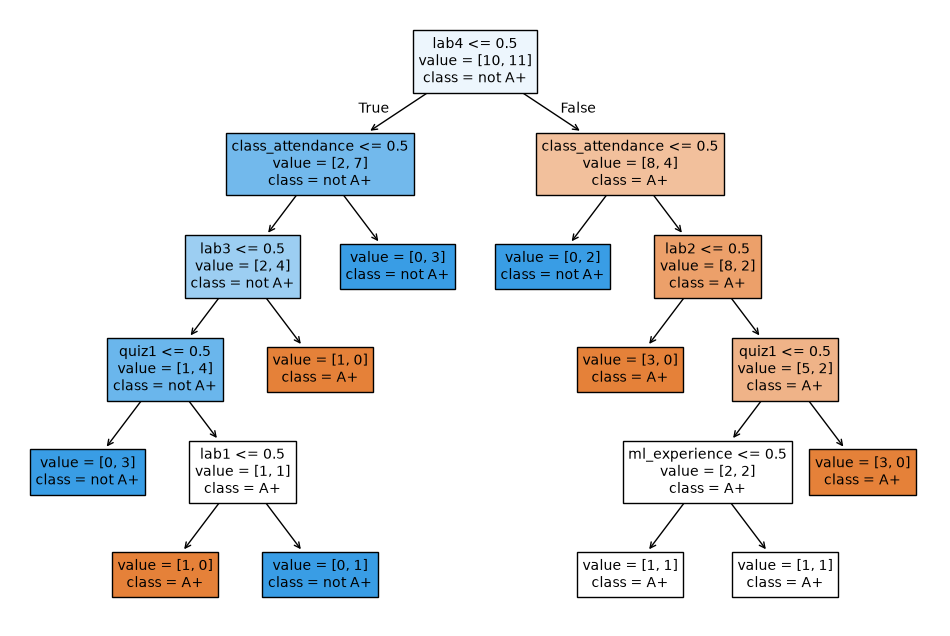

In [32]:
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

What's the prediction for the new example?

In [33]:
model.predict(new_example)

/Users/kvarada/CS/2026-27/cpsc330-book/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['A+'], dtype=object)

To predict for a new example, begin at the root, answer the question at each node, and follow the corresponding branch. The leaf at the end of the path supplies the prediction. Features that do not appear along that path do not affect that prediction.

### How does fitting work conceptually?

During fitting, the algorithm searches over many possible feature-and-threshold questions and possible orders in which to ask them. It prefers questions that divide the training examples into increasingly homogeneous groups. The selected questions and thresholds become model parameters.

![](img/fruit-tree.png)

### Choosing splits

At each node, a classification tree compares candidate questions using a measure of class impurity. Common criteria include the Gini index and entropy. A question is useful when the resulting groups contain more certain, homogeneous outcomes. The exact search and optimization details are beyond this course, but the result is a hierarchy of data-derived rules.

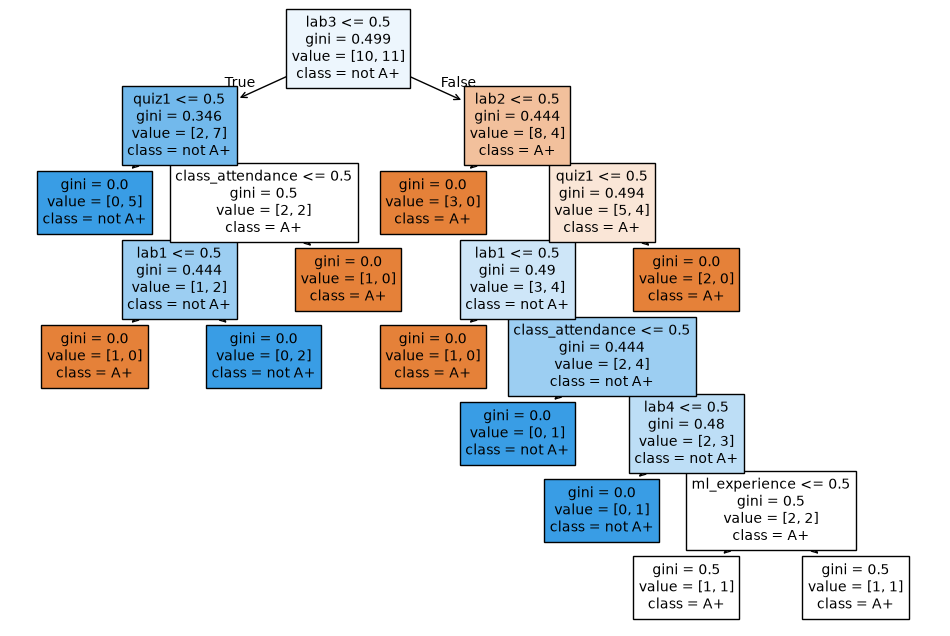

In [34]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()  # Create a decision tree
model.fit(X_binary, y)  # Fit a decision tree
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    fontsize=10,
)

::: {.callout-note}
Decision trees can split both categorical representations and numerical features. For a numerical feature, fitting also learns a threshold—for example, `quiz1 <= 88.5`.
:::

### Trees with numerical features

In [35]:
X.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1
0,1,1,92,93,84,91,92
1,1,0,94,90,80,83,91
2,0,0,78,85,83,80,80
3,0,1,91,94,92,91,89
4,0,1,77,83,90,92,85


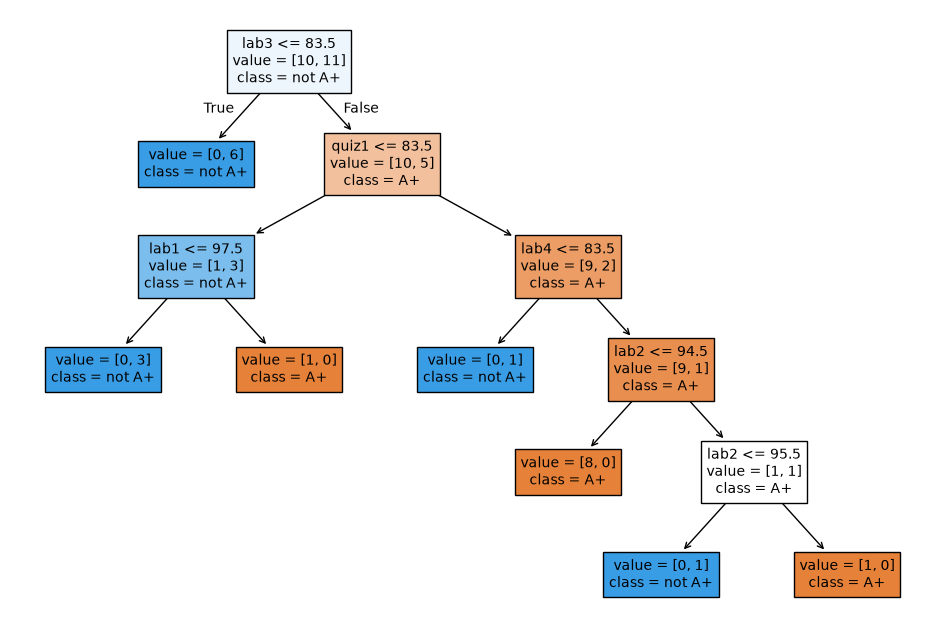

In [36]:
model = DecisionTreeClassifier()
model.fit(X, y)
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

### Decision trees for regression

Decision trees can also predict numerical targets. A `DecisionTreeRegressor` uses the same `fit` and `predict` interface, but chooses splits using a regression criterion such as squared error. Its default `score` is $R^2$, which can be negative when predictions are worse than the mean baseline.

In [37]:
regression_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-regression.csv")
regression_df.head()

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,90
1,1,0,94,90,80,83,91,84
2,0,0,78,85,83,80,80,82
3,0,1,91,94,92,91,89,92
4,0,1,77,83,90,92,85,90


In [38]:
X = regression_df.drop(["quiz2"], axis=1)
y = regression_df["quiz2"]

depth = 2
reg_model = DecisionTreeRegressor(max_depth=depth)
reg_model.fit(X, y)
regression_df["predicted_quiz2"] = reg_model.predict(X)
print("R^2 score on the training data: %0.3f\n\n" % (reg_model.score(X, y)))
regression_df.head()

R^2 score on the training data: 0.989




,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2,predicted_quiz2
0,1,1,92,93,84,91,92,90,90.333333
1,1,0,94,90,80,83,91,84,83.000000
2,0,0,78,85,83,80,80,82,83.000000
3,0,1,91,94,92,91,89,92,92.000000
4,0,1,77,83,90,92,85,90,90.333333


### Exercise 2.6: Baselines and decision trees

Select all true statements.

- (A) Changing the feature representation necessarily changes a most-frequent `DummyClassifier` prediction.
- (B) `predict` receives `X`, whereas `fit` and `score` receive both `X` and `y`.
- (C) Decision-tree features must be binary.
- (D) A decision tree predicts by routing an example from the root to a leaf.

::: {.callout-tip collapse="true" title="Solution"}
B and D are true. A most-frequent baseline ignores `X`, and decision trees can split numerical features by learning thresholds.
:::

## Model controls and decision boundaries

We now separate what a tree learns from the choices that control how it learns, then visualize how those choices affect its predictions.

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/KEtsfXn4w2E) discusses parameters, hyperparameters, and decision boundaries.
:::

### Parameters

Fitting a decision tree determines which feature to inspect and which threshold to use at each node. These learned values are the model's **parameters**. They are stored by the fitted estimator and used during prediction.

In [39]:
classification_df = pd.read_csv(DATA_DIR + "quiz2-grade-toy-classification.csv")
X = classification_df.drop(columns=["quiz2"])
y = classification_df["quiz2"]
model = DecisionTreeClassifier()
model.fit(X, y);

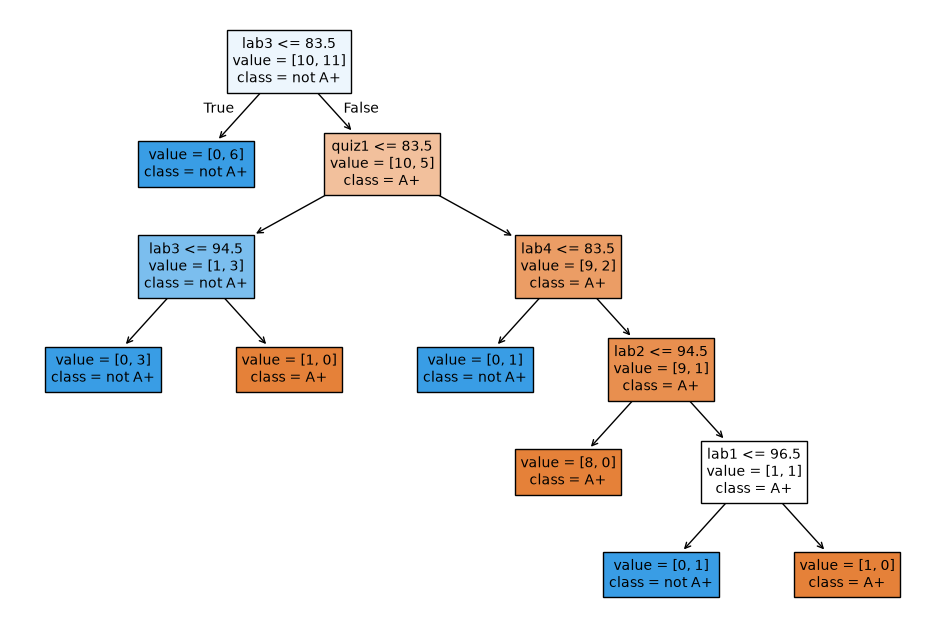

In [40]:
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=10,
)

With the default settings, a decision tree can continue splitting until its leaves are pure or another stopping condition is reached.

A very deep tree may create rules that describe only one or two training examples. We can control this behavior with hyperparameters such as the maximum tree depth.

### A decision stump: `max_depth=1`

A tree with one split is called a **decision stump**.

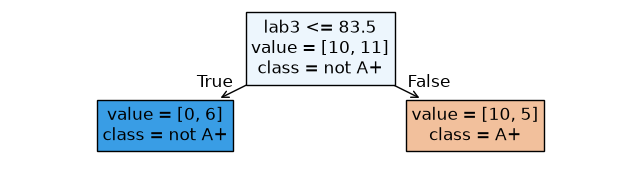

In [41]:
model = DecisionTreeClassifier(max_depth=1)
model.fit(X, y)
width = 8
height = 2
plt.figure(figsize=(width, height))
custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=12,
)  # custom function defined in code/utils.py

`max_depth` is a **hyperparameter**: a setting chosen before fitting that controls which trees the algorithm is allowed to learn.

### A deeper tree: `max_depth=3`

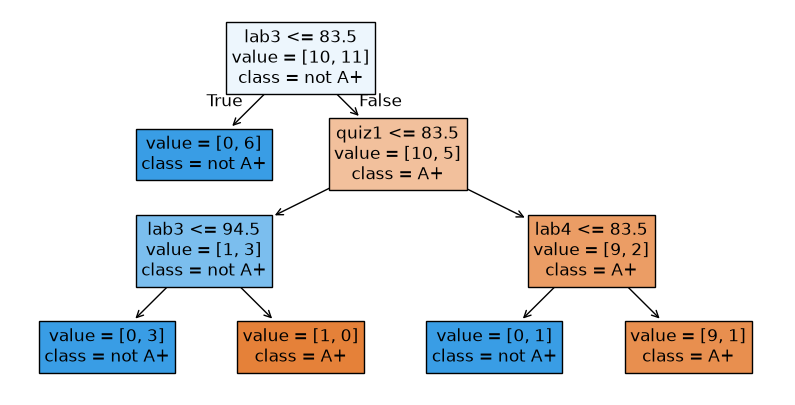

In [42]:
model = DecisionTreeClassifier(
    max_depth=3
)  # Let's try another value for the hyperparameter
model.fit(X, y)
width = 10
height = 5
plt.figure(figsize=(width, height))

custom_plot_tree(
    model,
    feature_names=X_binary.columns.tolist(),
    class_names=["A+", "not A+"],
    impurity=False,
    fontsize=12,
)

### Parameters and hyperparameters

**Parameters**
: Values learned from data during `fit`, such as split features and thresholds. The fitted model needs them to make predictions.

**Hyperparameters**
: Settings chosen before `fit` that control the learning process or model family. They may be selected using domain knowledge, heuristics, or a systematic validation procedure.

::: {.callout-important}
In `scikit-learn`, hyperparameters are normally supplied when an estimator is constructed. Fitted parameters are learned later by calling `fit`.
:::

Besides `max_depth`, commonly used decision-tree hyperparameters include `min_samples_split`, `min_samples_leaf`, and `max_leaf_nodes`. Each constrains the complexity of the learned tree in a different way.

::: {.callout-tip title="See also"}
See the [`DecisionTreeClassifier` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for the complete estimator interface and hyperparameters.
:::

### Decision boundaries

A fitted classifier partitions the possible feature values into regions assigned to different classes. The border between those regions is its **decision boundary**. With two features, we can draw this boundary and see how model complexity changes it.

#### Quiz-grade example

For visualization, we fit trees using only `lab4` and `quiz1`.

In [43]:
X_subset = X[["lab4", "quiz1"]]
X_subset.head()

,lab4,quiz1
0,91,92
1,83,91
2,80,80
3,91,89
4,92,85


##### Decision boundary with `max_depth=1`

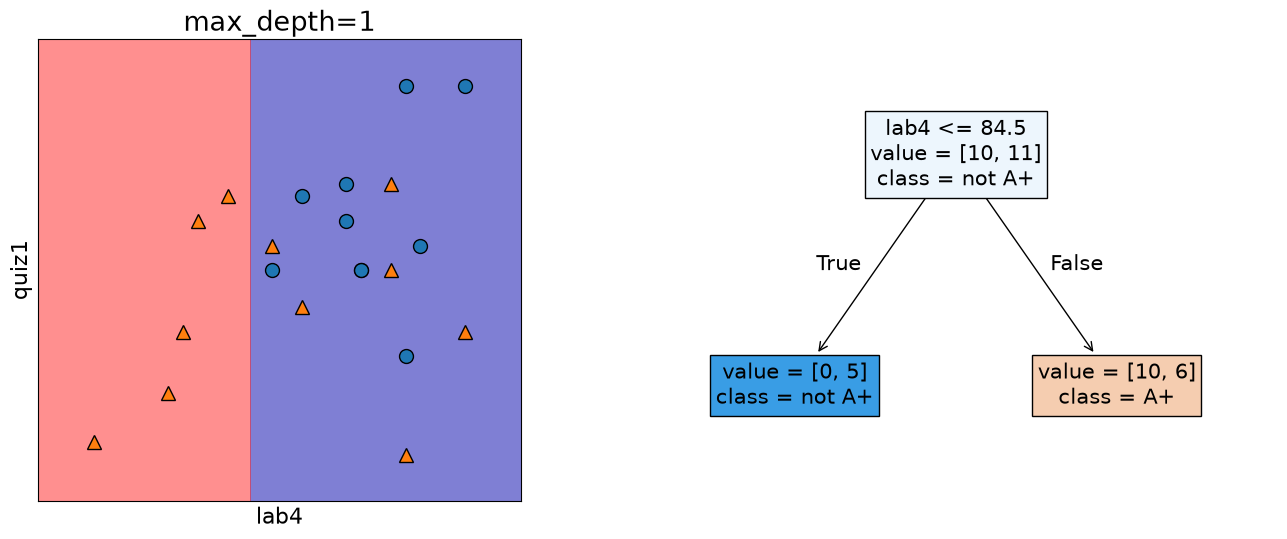

In [44]:
depth = 1  # decision stump
model = DecisionTreeClassifier(max_depth=depth)
model.fit(X_subset.values, y)
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=15
)

The two colored regions show the classes predicted for possible combinations of `lab4` and `quiz1`. A depth-one tree creates a single horizontal or vertical boundary because it asks one threshold question.

##### Decision boundary with `max_depth=2`

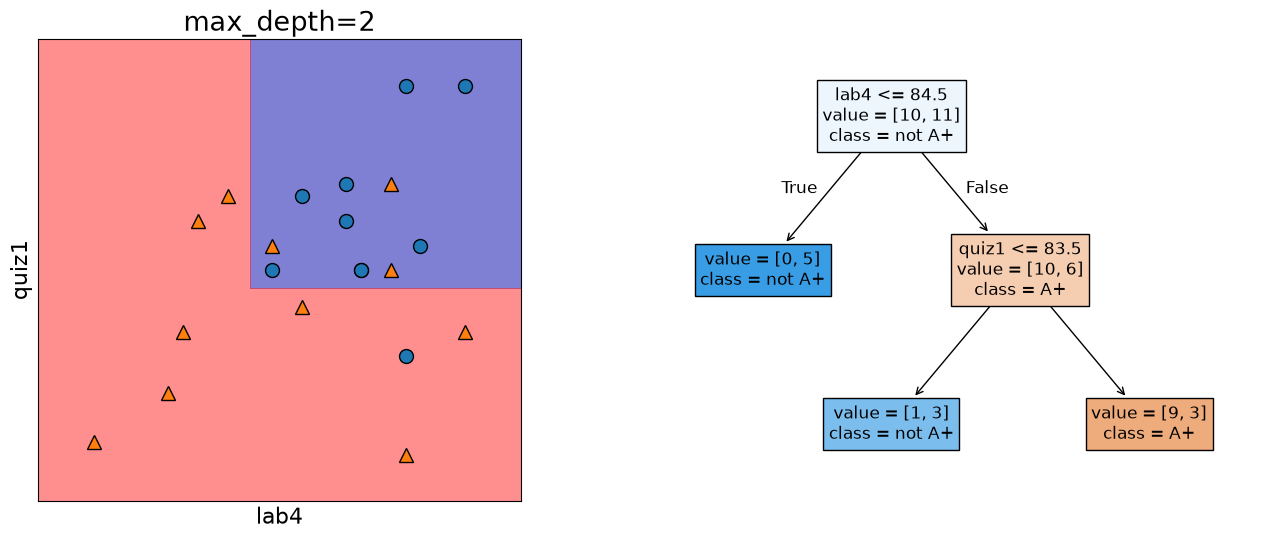

In [45]:
model = DecisionTreeClassifier(max_depth=2)
model.fit(X_subset.values, y)
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=12
)

A second level allows the model to divide another region, producing a more detailed decision boundary.

##### Decision boundary with `max_depth=5`

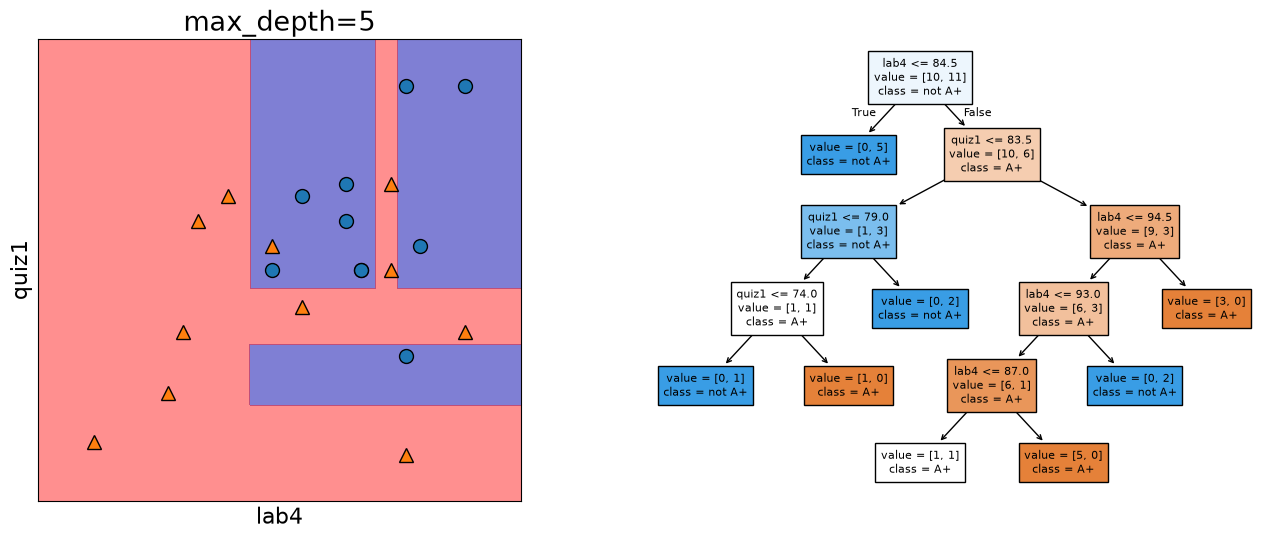

In [46]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_subset.values, y)
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=8
)

At depth five, the boundary follows the training examples much more closely. Greater detail lowers training error, but whether it improves predictions for new examples remains unresolved.

#### Canada–USA cities example

Suppose we observe the longitude, latitude, and country of several cities near the Canada–USA border. Can a decision tree learn a boundary that predicts the country of a new coordinate?

In [47]:
### US Canada cities data
df = pd.read_csv(DATA_DIR + "canada_usa_cities.csv")
df

,longitude,latitude,country
0,-130.0437,55.9773,USA
1,-134.4197,58.3019,USA
2,-123.0780,48.9854,USA
3,-122.7436,48.9881,USA
4,-122.2691,48.9951,USA
...,...,...,...
204,-72.7218,45.3990,Canada
205,-66.6458,45.9664,Canada
206,-79.2506,42.9931,Canada
207,-72.9406,45.6275,Canada


In [48]:
X = df[["longitude", "latitude"]]

In [49]:
y = df["country"]

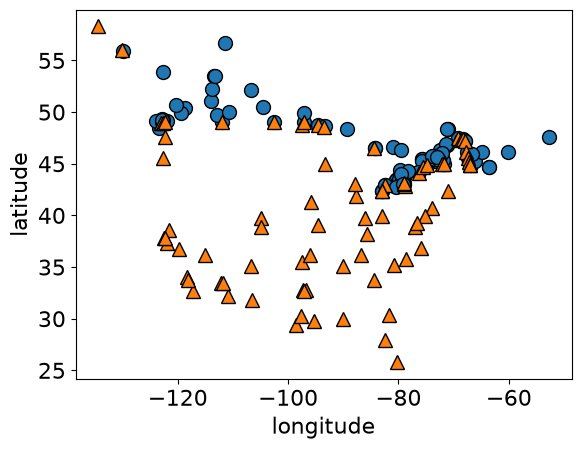

In [50]:
mglearn.discrete_scatter(X.iloc[:, 0], X.iloc[:, 1], y)
plt.xlabel("longitude")
plt.ylabel("latitude");

##### The geographic boundary

In reality, the Canada–USA boundary is known:

![](img/canada-us-border.jpg)

[Image source](https://sovereignlimits.com/blog/u-s-canada-border-history-disputes)

Our model does not receive this boundary. It approximates one using only the limited labeled examples in the training data.

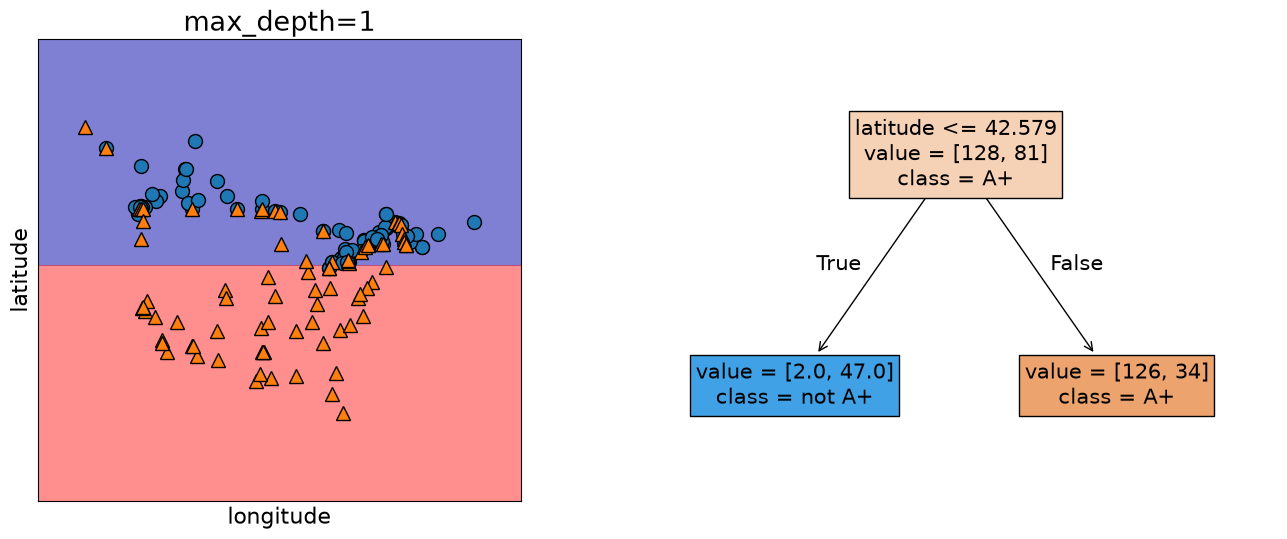

In [51]:
model = DecisionTreeClassifier(max_depth=1)
model.fit(X.values, y)
plot_tree_decision_boundary_and_tree(
    model,
    X,
    y,
    height=6,
    width=16,
    fontsize=15,
    eps=10,
    x_label="longitude",
    y_label="latitude",
)

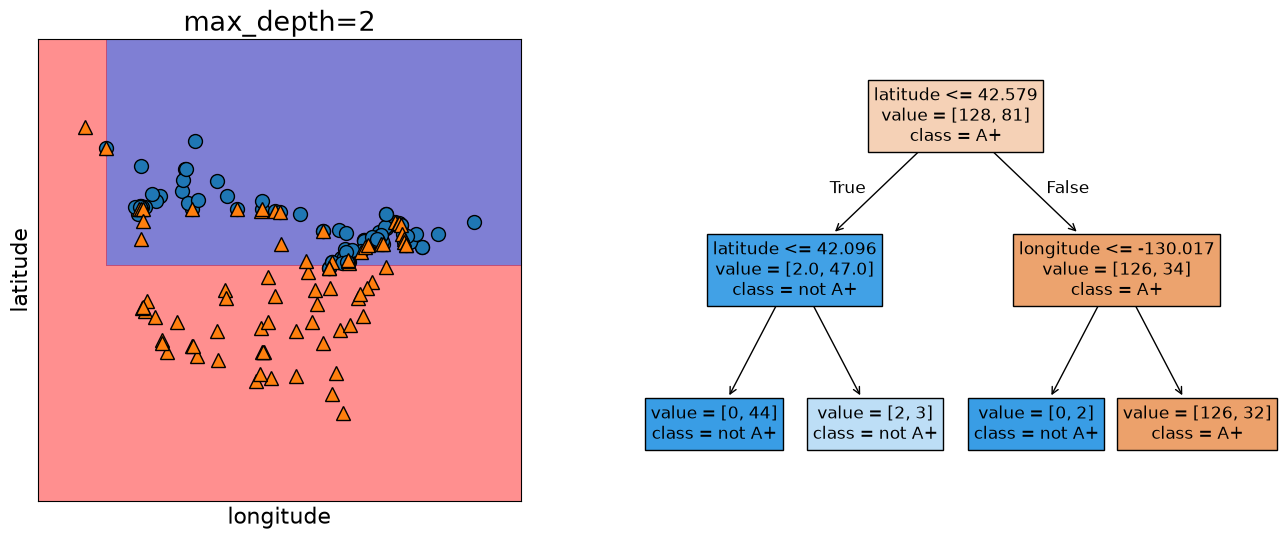

In [52]:
model = DecisionTreeClassifier(max_depth=2)
model.fit(X.values, y)
plot_tree_decision_boundary_and_tree(
    model,
    X,
    y,
    height=6,
    width=16,
    fontsize=12,
    eps=10,
    x_label="longitude",
    y_label="latitude",
)

## Summary

This chapter established the vocabulary and workflow used throughout the book:

- examples are represented by feature rows in $X$, with targets in $y$;
- classification predicts discrete labels, whereas regression predicts numerical values;
- baselines provide reference performance that a useful model should improve upon;
- `scikit-learn` estimators share the `fit` and `predict` interface, while `score` is model-dependent;
- decision trees learn hierarchies of feature-threshold questions;
- fitted split features and thresholds are parameters, while settings such as `max_depth` are hyperparameters; and
- increasing tree depth creates a more detailed decision boundary and can reduce training error.

::: {.callout-warning title="The question that remains"}
A sufficiently deep tree can classify every training example correctly. Does that mean it will predict new examples well? Chapter 3 introduces data splitting, cross-validation, underfitting, and overfitting to answer this question.
:::